# Notebook 05 : Forecasting Clôture Mensuelle 

**PFE 2026 - Malek - ESB**

## Objectif Business

**Question** : Combien de ventes Orange Tunisie va réaliser à la 
fin du mois en cours ?

## 5 Approches de Forecasting comparées

### Méthodes statistiques classiques
1. **ARIMA / SARIMA** : modèles auto-régressifs

### Machine Learning
2. **ML temporel** : XGBoost + Random Forest avec features temporelles

### Méthodes modernes
3. **Prophet (Meta)** : décomposition automatique

### Deep Learning
4. **LSTM (Long Short-Term Memory)** : réseaux récurrents
5. **Attention/Transformer** (simplifié)

## Métriques d'évaluation

- **MAE** : erreur absolue moyenne
- **RMSE** : erreur quadratique moyenne
- **MAPE** : pourcentage d'erreur

## Démarche scientifique

1. Chargement de l'historique des ventes
2. Application des 5 approches
3. Comparaison rigoureuse
4. Sélection de la meilleure approche
5. Prédiction du mois en cours

In [1]:
# === IMPORTS COMPLETS ===

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine, text
from pathlib import Path
from dotenv import load_dotenv
import os
import time
from datetime import datetime, timedelta

# Statistique - ARIMA
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Machine Learning
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import xgboost as xgb

# Prophet
from prophet import Prophet

# Deep Learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import MinMaxScaler

import warnings
warnings.filterwarnings('ignore')

# Configuration
%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

# Couleurs
COLOR_ORANGE = '#FF6600'
COLOR_GREEN = '#28A745'
COLOR_RED = '#DC3545'
COLOR_BLUE = '#0066CC'
COLOR_PURPLE = '#9C27B0'

# Reproductibilite
np.random.seed(42)
tf.random.set_seed(42)

print("Bibliotheques chargees !")
print(f"Prophet pret !")
print(f"TensorFlow : {tf.__version__}")

Bibliotheques chargees !
Prophet pret !
TensorFlow : 2.21.0


In [2]:
# === CONNEXION POSTGRESQL ===

PROJECT_ROOT = Path.cwd().parent
load_dotenv(PROJECT_ROOT / ".env")

DB_HOST = os.getenv("DB_HOST", "localhost")
DB_PORT = os.getenv("DB_PORT", "5432")
DB_NAME = os.getenv("DB_NAME", "orange_dwh")
DB_USER = os.getenv("DB_USER", "postgres")
DB_PASSWORD = os.getenv("DB_PASSWORD", "")

engine = create_engine(
    f"postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
)

with engine.connect() as conn:
    result = conn.execute(text("SELECT 1")).fetchone()
print(f"Connexion OK : {result}")

Connexion OK : (1,)


## 1. Chargement de l'historique des ventes par jour

In [3]:
# === CHARGEMENT VENTES PAR JOUR ===

query = """
SELECT 
    DATE(date_vente) AS date_jour,
    COUNT(*) AS nb_ventes,
    ROUND(SUM(first_month_bill)::numeric, 2) AS ca_jour
FROM fact_ventes
WHERE date_vente IS NOT NULL
GROUP BY DATE(date_vente)
ORDER BY date_jour;
"""

df = pd.read_sql(query, engine)
df['date_jour'] = pd.to_datetime(df['date_jour'])

print(f"Periode : {df['date_jour'].min().date()} -> {df['date_jour'].max().date()}")
print(f"Nombre de jours : {len(df):,}")
print(f"Total ventes : {df['nb_ventes'].sum():,}")
print(f"Moyenne par jour : {df['nb_ventes'].mean():.0f}")

df.head()

Periode : 2024-11-01 -> 2025-03-31
Nombre de jours : 150
Total ventes : 63,615
Moyenne par jour : 424


,date_jour,nb_ventes,ca_jour
0,2024-11-01,1025,985.0
1,2024-11-02,529,486.0
2,2024-11-03,54,53.0
3,2024-11-04,610,568.0
4,2024-11-05,524,504.0


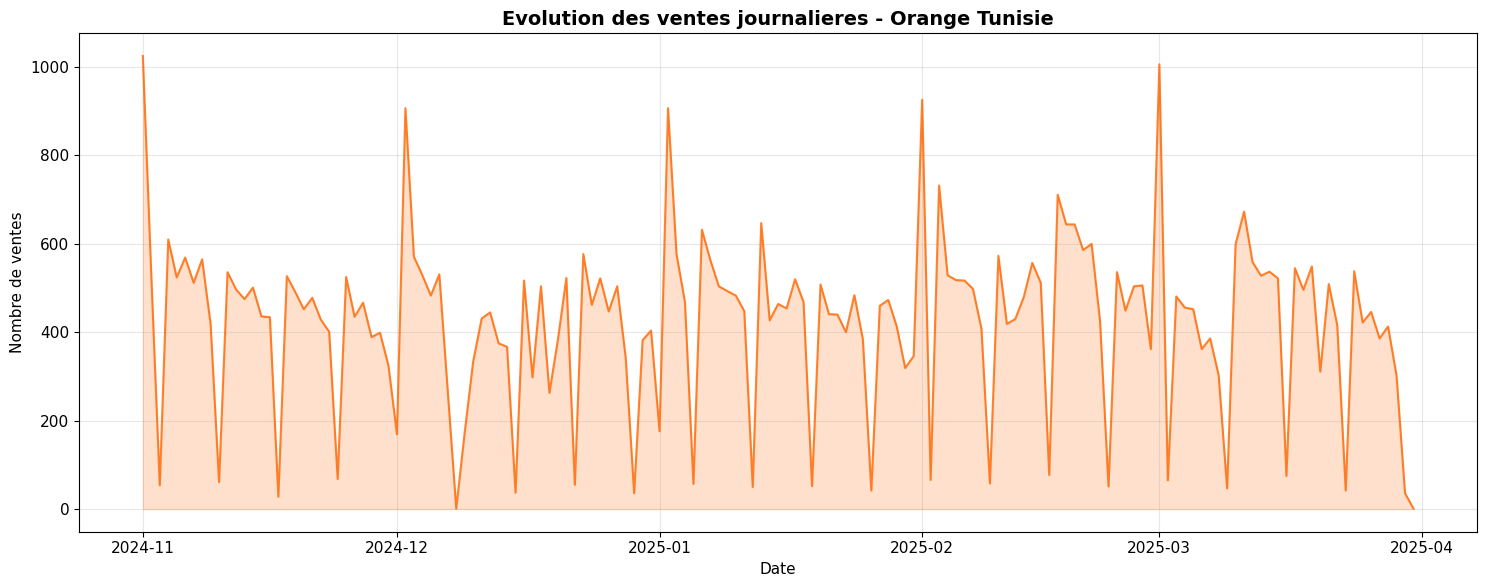

In [4]:
# === VISUALISATION SERIE TEMPORELLE ===

fig, ax = plt.subplots(figsize=(15, 6))

ax.plot(df['date_jour'], df['nb_ventes'],
        color=COLOR_ORANGE, linewidth=1.5, alpha=0.8)
ax.fill_between(df['date_jour'], df['nb_ventes'],
                color=COLOR_ORANGE, alpha=0.2)
ax.set_title('Evolution des ventes journalieres - Orange Tunisie',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Nombre de ventes')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 2. Préparation Train/Test

Pour les séries temporelles, on split **chronologiquement** :
- 80% premières dates → entraînement
- 20% dernières dates → test

In [5]:
# === SPLIT TRAIN/TEST CHRONOLOGIQUE ===

# 80% train, 20% test
split_idx = int(len(df) * 0.8)

train = df.iloc[:split_idx].copy()
test = df.iloc[split_idx:].copy()

print(f"Train : {len(train)} jours ({train['date_jour'].min().date()} -> {train['date_jour'].max().date()})")
print(f"Test  : {len(test)} jours ({test['date_jour'].min().date()} -> {test['date_jour'].max().date()})")

# Structure pour stocker les resultats
results_forecast = []

def evaluate_forecast(name, y_true, y_pred, training_time):
    """Calcule les metriques d'un modele de forecasting."""
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    
    results_forecast.append({
        'Approche': name,
        'MAE': mae,
        'RMSE': rmse,
        'MAPE': mape,
        'Temps_s': training_time
    })
    
    print(f"\n>> {name}")
    print(f"   MAE   : {mae:.2f} ventes")
    print(f"   RMSE  : {rmse:.2f} ventes")
    print(f"   MAPE  : {mape:.2f}%")
    print(f"   Temps : {training_time:.2f}s")

print("\nStructure de comparaison prete !")

Train : 120 jours (2024-11-01 -> 2025-03-01)
Test  : 30 jours (2025-03-02 -> 2025-03-31)

Structure de comparaison prete !


## 3. Approche 1 : ARMA / ARIMA / SARIMA

Trois modèles statistiques classiques pour séries temporelles :

### 3.1 ARMA (AutoRegressive Moving Average)
- Pour données **STATIONNAIRES**
- Combine auto-régression (AR) et moyenne mobile (MA)
- ARMA(p, q) : p termes AR + q termes MA

### 3.2 ARIMA (AutoRegressive Integrated Moving Average)
- Pour données **NON-STATIONNAIRES**
- ARMA + **différenciation** (d)
- ARIMA(p, d, q)

### 3.3 SARIMA (Seasonal ARIMA)
- ARIMA + **saisonnalité**
- Capture les cycles répétitifs (hebdo, annuel)
- SARIMA(p, d, q)(P, D, Q, s) où s = période saisonnière

### Notation utilisée
- **p** : ordre auto-régressif
- **d** : ordre de différenciation
- **q** : ordre de moyenne mobile
- **s** : période saisonnière (s=7 pour hebdomadaire)

In [7]:
# === 1. ARMA / ARIMA / SARIMA ===

from statsmodels.tsa.arima.model import ARIMA

print("=" * 60)
print("APPROCHE 1 : MODELES STATISTIQUES (ARMA, ARIMA, SARIMA)")
print("=" * 60)

# ============================================================
# 1.A - ARMA (donnees stationnaires)
# ============================================================
print("\n1.A - Entrainement ARMA(2,2)...")
print("(ARMA : sans differenciation)")

start = time.time()

# ARMA = ARIMA(p, 0, q) - sans differenciation
arma_model = ARIMA(
    train['nb_ventes'].values,
    order=(2, 0, 2)  # p=2, d=0 (pas de differenciation), q=2
)

arma_fit = arma_model.fit()
y_pred_arma = arma_fit.forecast(steps=len(test))

elapsed = time.time() - start
evaluate_forecast('ARMA(2,0,2)', test['nb_ventes'].values, y_pred_arma, elapsed)


# ============================================================
# 1.B - ARIMA (donnees non-stationnaires)
# ============================================================
print("\n1.B - Entrainement ARIMA(1,1,1)...")
print("(ARIMA : avec differenciation d=1)")

start = time.time()

# ARIMA avec differenciation pour rendre stationnaire
arima_model = ARIMA(
    train['nb_ventes'].values,
    order=(1, 1, 1)  # p=1, d=1 (differenciation), q=1
)

arima_fit = arima_model.fit()
y_pred_arima = arima_fit.forecast(steps=len(test))

elapsed = time.time() - start
evaluate_forecast('ARIMA(1,1,1)', test['nb_ventes'].values, y_pred_arima, elapsed)


# ============================================================
# 1.C - SARIMA (avec saisonnalite)
# ============================================================
print("\n1.C - Entrainement SARIMA(1,1,1)(1,1,1,7)...")
print("(SARIMA : avec saisonnalite hebdomadaire s=7)")
print("Cela peut prendre 30s - 1 min...")

start = time.time()

# SARIMA(p,d,q)(P,D,Q,s)
# Saisonnalite hebdomadaire (s=7)
sarima_model = SARIMAX(
    train['nb_ventes'].values,
    order=(1, 1, 1),                    # ARIMA
    seasonal_order=(1, 1, 1, 7),        # Saisonnalite hebdomadaire
)

sarima_fit = sarima_model.fit(disp=False)
y_pred_sarima = sarima_fit.forecast(steps=len(test))

elapsed = time.time() - start
evaluate_forecast('SARIMA(1,1,1)(1,1,1,7)', test['nb_ventes'].values, y_pred_sarima, elapsed)


# ============================================================
# COMPARAISON DES 3 MODELES STATISTIQUES
# ============================================================
print("\n" + "=" * 60)
print("COMPARAISON DES 3 MODELES STATISTIQUES")
print("=" * 60)
print("ARMA   : sans differenciation, sans saisonnalite")
print("ARIMA  : avec differenciation, sans saisonnalite")
print("SARIMA : avec differenciation, AVEC saisonnalite")

APPROCHE 1 : MODELES STATISTIQUES (ARMA, ARIMA, SARIMA)

1.A - Entrainement ARMA(2,2)...
(ARMA : sans differenciation)

>> ARMA(2,0,2)
   MAE   : 133.72 ventes
   RMSE  : 183.63 ventes
   MAPE  : 1904.20%
   Temps : 0.60s

1.B - Entrainement ARIMA(1,1,1)...
(ARIMA : avec differenciation d=1)

>> ARIMA(1,1,1)
   MAE   : 141.56 ventes
   RMSE  : 196.79 ventes
   MAPE  : 1650.13%
   Temps : 0.21s

1.C - Entrainement SARIMA(1,1,1)(1,1,1,7)...
(SARIMA : avec saisonnalite hebdomadaire s=7)
Cela peut prendre 30s - 1 min...

>> SARIMA(1,1,1)(1,1,1,7)
   MAE   : 151.06 ventes
   RMSE  : 213.34 ventes
   MAPE  : 2329.60%
   Temps : 0.50s

COMPARAISON DES 3 MODELES STATISTIQUES
ARMA   : sans differenciation, sans saisonnalite
ARIMA  : avec differenciation, sans saisonnalite
SARIMA : avec differenciation, AVEC saisonnalite


## 4. Approche 2 : Machine Learning (XGBoost + RF)

On crée des **features temporelles** puis on applique des modèles ML :
- Jour de la semaine
- Mois
- Tendance (jour numéro)
- Lag features (ventes précédentes)

In [8]:
# === 2. ML AVEC FEATURES TEMPORELLES ===

print("Preparation des features temporelles...")

# Creer features temporelles
def create_time_features(df_input):
    df_feat = df_input.copy()
    df_feat['jour_semaine'] = df_feat['date_jour'].dt.dayofweek
    df_feat['mois'] = df_feat['date_jour'].dt.month
    df_feat['jour_mois'] = df_feat['date_jour'].dt.day
    df_feat['trend'] = range(len(df_feat))
    
    # Lag features (ventes 1, 7, 14 jours avant)
    df_feat['lag_1'] = df_feat['nb_ventes'].shift(1)
    df_feat['lag_7'] = df_feat['nb_ventes'].shift(7)
    df_feat['lag_14'] = df_feat['nb_ventes'].shift(14)
    
    # Rolling averages
    df_feat['rolling_7'] = df_feat['nb_ventes'].rolling(7).mean()
    
    return df_feat

df_features = create_time_features(df)
df_features = df_features.dropna()

# Re-split apres creation des lags
split_idx_ml = int(len(df_features) * 0.8)
train_ml = df_features.iloc[:split_idx_ml]
test_ml = df_features.iloc[split_idx_ml:]

features_cols = ['jour_semaine', 'mois', 'jour_mois', 'trend', 
                 'lag_1', 'lag_7', 'lag_14', 'rolling_7']

X_train_ml = train_ml[features_cols].values
y_train_ml = train_ml['nb_ventes'].values
X_test_ml = test_ml[features_cols].values
y_test_ml = test_ml['nb_ventes'].values

print(f"Features creees : {features_cols}")
print(f"Train ML : {X_train_ml.shape[0]} jours")
print(f"Test ML  : {X_test_ml.shape[0]} jours")

# === XGBOOST ===
print("\nEntrainement XGBoost...")
start = time.time()
xgb_ts = xgb.XGBRegressor(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42)
xgb_ts.fit(X_train_ml, y_train_ml)
y_pred_xgb_ts = xgb_ts.predict(X_test_ml)
elapsed = time.time() - start

evaluate_forecast('XGBoost (features temporelles)', y_test_ml, y_pred_xgb_ts, elapsed)

# === RANDOM FOREST ===
print("\nEntrainement Random Forest...")
start = time.time()
rf_ts = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_ts.fit(X_train_ml, y_train_ml)
y_pred_rf_ts = rf_ts.predict(X_test_ml)
elapsed = time.time() - start

evaluate_forecast('Random Forest (features temporelles)', y_test_ml, y_pred_rf_ts, elapsed)

Preparation des features temporelles...
Features creees : ['jour_semaine', 'mois', 'jour_mois', 'trend', 'lag_1', 'lag_7', 'lag_14', 'rolling_7']
Train ML : 108 jours
Test ML  : 28 jours

Entrainement XGBoost...

>> XGBoost (features temporelles)
   MAE   : 82.12 ventes
   RMSE  : 118.35 ventes
   MAPE  : 1242.77%
   Temps : 0.32s

Entrainement Random Forest...

>> Random Forest (features temporelles)
   MAE   : 91.81 ventes
   RMSE  : 128.43 ventes
   MAPE  : 1566.37%
   Temps : 0.29s


## 5. Approche 3 : Prophet (Meta)

**Prophet** capture automatiquement :
- Tendance non-linéaire
- Saisonnalité hebdomadaire et annuelle
- Effets de jours fériés

In [9]:
# === 3. PROPHET ===

print("Entrainement Prophet...")

start = time.time()

# Format Prophet : ds, y
df_prophet_train = train[['date_jour', 'nb_ventes']].copy()
df_prophet_train.columns = ['ds', 'y']

# Modele
prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
)

prophet_model.fit(df_prophet_train)

# Predictions
future = prophet_model.make_future_dataframe(periods=len(test))
forecast_prophet = prophet_model.predict(future)

# Extraire predictions test
y_pred_prophet = forecast_prophet.iloc[-len(test):]['yhat'].values

elapsed = time.time() - start

evaluate_forecast('Prophet (Meta)', test['nb_ventes'].values, y_pred_prophet, elapsed)

Entrainement Prophet...


17:44:26 - cmdstanpy - INFO - Chain [1] start processing
17:44:26 - cmdstanpy - INFO - Chain [1] done processing



>> Prophet (Meta)
   MAE   : 366.18 ventes
   RMSE  : 390.09 ventes
   MAPE  : 3013.67%
   Temps : 0.74s


## 6. Approche 4 : LSTM (Long Short-Term Memory)

**LSTM** est un type de RNN capable de capturer les dépendances 
à long terme dans les séries temporelles.

Preparation des donnees pour LSTM...
X_train shape : (113, 7, 1)
X_test shape : (23, 7, 1)

Entrainement LSTM...
Cela peut prendre 1-2 minutes...

>> LSTM (Deep Learning)
   MAE   : 144.75 ventes
   RMSE  : 191.57 ventes
   MAPE  : 2066.97%
   Temps : 16.32s


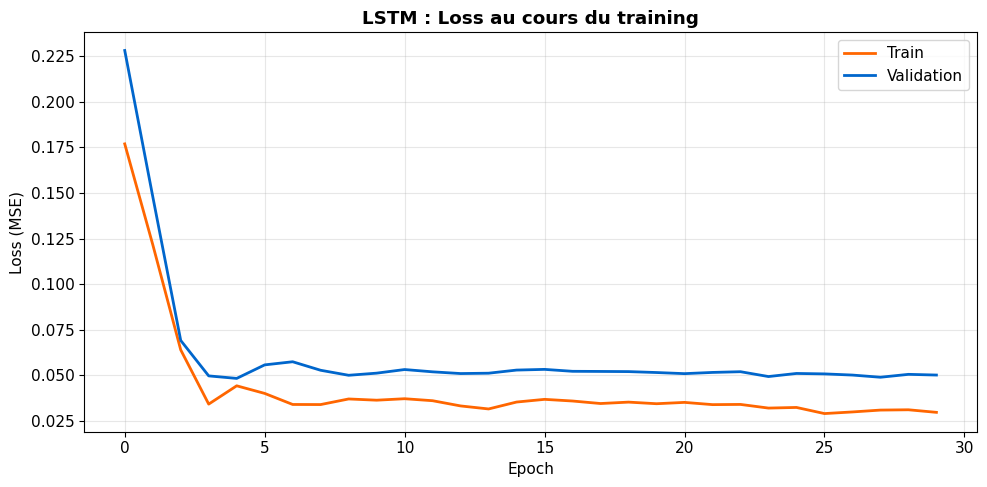

In [10]:
# === 4. LSTM (DEEP LEARNING) ===

print("Preparation des donnees pour LSTM...")

start = time.time()

# Normaliser
scaler_lstm = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler_lstm.fit_transform(train['nb_ventes'].values.reshape(-1, 1))
test_scaled = scaler_lstm.transform(test['nb_ventes'].values.reshape(-1, 1))

# Creer sequences (look_back = 7 jours)
look_back = 7

def create_sequences(data, look_back=7):
    X, y = [], []
    for i in range(len(data) - look_back):
        X.append(data[i:(i + look_back), 0])
        y.append(data[i + look_back, 0])
    return np.array(X), np.array(y)

X_train_lstm, y_train_lstm = create_sequences(train_scaled, look_back)
X_test_lstm, y_test_lstm = create_sequences(test_scaled, look_back)

# Reshape pour LSTM [samples, time steps, features]
X_train_lstm = X_train_lstm.reshape((X_train_lstm.shape[0], X_train_lstm.shape[1], 1))
X_test_lstm = X_test_lstm.reshape((X_test_lstm.shape[0], X_test_lstm.shape[1], 1))

print(f"X_train shape : {X_train_lstm.shape}")
print(f"X_test shape : {X_test_lstm.shape}")

# Architecture LSTM
print("\nEntrainement LSTM...")
print("Cela peut prendre 1-2 minutes...")

lstm_model = keras.Sequential([
    layers.LSTM(50, activation='relu', input_shape=(look_back, 1), return_sequences=True),
    layers.Dropout(0.2),
    layers.LSTM(50, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(1)
])

lstm_model.compile(optimizer='adam', loss='mse', metrics=['mae'])

history_lstm = lstm_model.fit(
    X_train_lstm, y_train_lstm,
    epochs=30,
    batch_size=16,
    validation_split=0.1,
    verbose=0
)

# Predictions
y_pred_lstm_scaled = lstm_model.predict(X_test_lstm, verbose=0)
y_pred_lstm = scaler_lstm.inverse_transform(y_pred_lstm_scaled).flatten()
y_test_lstm_real = scaler_lstm.inverse_transform(y_test_lstm.reshape(-1, 1)).flatten()

elapsed = time.time() - start

evaluate_forecast('LSTM (Deep Learning)', y_test_lstm_real, y_pred_lstm, elapsed)

# Plot historique
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(history_lstm.history['loss'], color=COLOR_ORANGE, label='Train', linewidth=2)
ax.plot(history_lstm.history['val_loss'], color=COLOR_BLUE, label='Validation', linewidth=2)
ax.set_title('LSTM : Loss au cours du training', fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss (MSE)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Approche 5 : Attention (Transformer simplifié)

**Mécanisme d'Attention** : modèle moderne qui pondère 
l'importance de chaque pas de temps.

In [11]:
# === 5. ATTENTION (Transformer simplifie) ===

print("Entrainement Attention Model...")
print("Cela peut prendre 2-3 minutes...")

start = time.time()

# Architecture avec Multi-Head Attention
def build_attention_model(input_shape):
    inputs = layers.Input(shape=input_shape)
    
    # Multi-Head Attention
    attention = layers.MultiHeadAttention(
        num_heads=4, 
        key_dim=32
    )(inputs, inputs)
    
    # Add & Norm
    x = layers.Add()([inputs, attention])
    x = layers.LayerNormalization()(x)
    
    # Feed Forward
    ff = layers.Dense(64, activation='relu')(x)
    ff = layers.Dense(input_shape[-1])(ff)
    
    # Add & Norm
    x = layers.Add()([x, ff])
    x = layers.LayerNormalization()(x)
    
    # Output
    x = layers.GlobalAveragePooling1D()(x)
    outputs = layers.Dense(1)(x)
    
    model = keras.Model(inputs, outputs)
    return model

attention_model = build_attention_model((look_back, 1))
attention_model.compile(optimizer='adam', loss='mse', metrics=['mae'])

history_att = attention_model.fit(
    X_train_lstm, y_train_lstm,
    epochs=30,
    batch_size=16,
    validation_split=0.1,
    verbose=0
)

# Predictions
y_pred_att_scaled = attention_model.predict(X_test_lstm, verbose=0)
y_pred_att = scaler_lstm.inverse_transform(y_pred_att_scaled).flatten()

elapsed = time.time() - start

evaluate_forecast('Attention (Transformer)', y_test_lstm_real, y_pred_att, elapsed)

Entrainement Attention Model...
Cela peut prendre 2-3 minutes...

>> Attention (Transformer)
   MAE   : 164.57 ventes
   RMSE  : 202.36 ventes
   MAPE  : 1862.04%
   Temps : 16.32s


## 8. Comparaison FINALE des 5 approches

In [12]:
# === TABLEAU COMPARATIF FINAL ===

df_results_fc = pd.DataFrame(results_forecast)
df_results_fc = df_results_fc.sort_values('MAPE').reset_index(drop=True)

# Ajouter le rang
df_results_fc.insert(0, 'Rang', range(1, len(df_results_fc) + 1))

# Marquer le meilleur
df_results_fc['Choix'] = ''
df_results_fc.loc[0, 'Choix'] = 'RETENU (TOP)'

print("CLASSEMENT FINAL DES 5 APPROCHES DE FORECASTING")
print("=" * 80)
print(df_results_fc.to_string(index=False))

print(f"\nMEILLEURE APPROCHE : {df_results_fc.iloc[0]['Approche']}")
print(f"  - MAE   : {df_results_fc.iloc[0]['MAE']:.2f}")
print(f"  - RMSE  : {df_results_fc.iloc[0]['RMSE']:.2f}")
print(f"  - MAPE  : {df_results_fc.iloc[0]['MAPE']:.2f}%")
print(f"  - Temps : {df_results_fc.iloc[0]['Temps_s']:.2f}s")

CLASSEMENT FINAL DES 5 APPROCHES DE FORECASTING
 Rang                             Approche        MAE       RMSE        MAPE   Temps_s        Choix
    1       XGBoost (features temporelles)  82.124069 118.349287 1242.772867  0.317581 RETENU (TOP)
    2 Random Forest (features temporelles)  91.813629 128.426398 1566.368499  0.289599             
    3                         ARIMA(1,1,1) 141.560747 196.790553 1650.127781  0.209624             
    4              Attention (Transformer) 164.568564 202.358465 1862.044473 16.324186             
    5                          ARMA(2,0,2) 133.715920 183.630370 1904.197339  0.603446             
    6                 LSTM (Deep Learning) 144.752382 191.568628 2066.972193 16.320660             
    7               SARIMA(1,1,1)(1,1,1,7) 151.058491 213.338537 2329.604254  0.497250             
    8                       Prophet (Meta) 366.183017 390.086009 3013.671581  0.741832             

MEILLEURE APPROCHE : XGBoost (features temporelles)

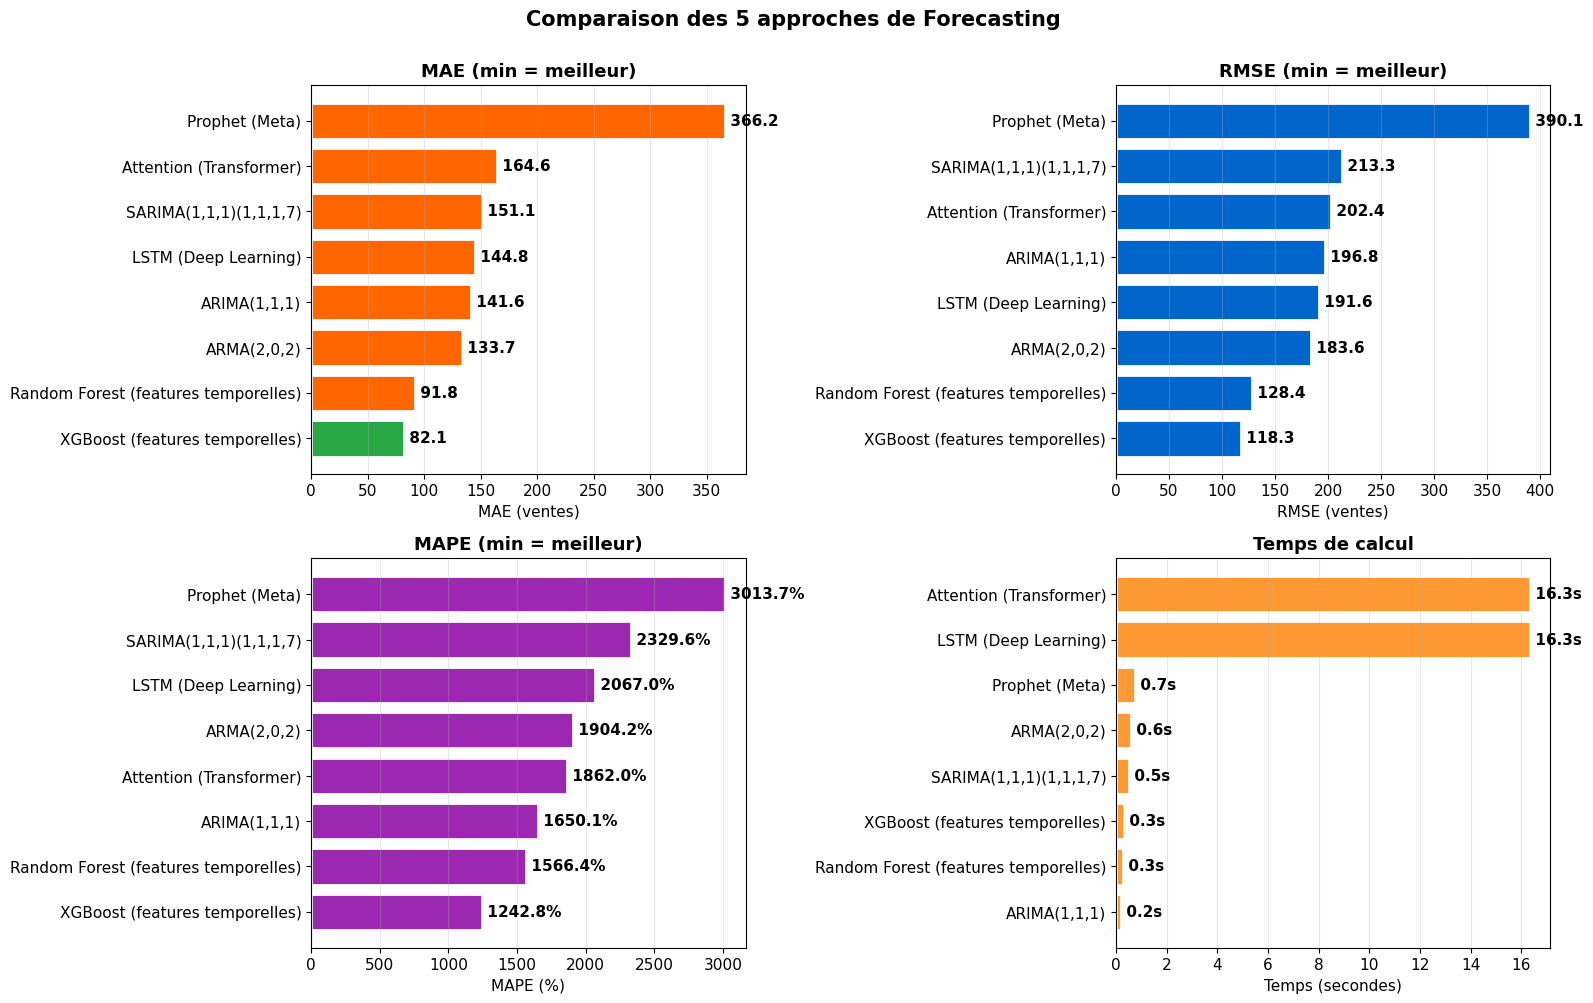

In [13]:
# === VISUALISATION COMPARATIVE ===

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. MAE
df_sorted = df_results_fc.sort_values('MAE')
colors_mae = [COLOR_GREEN if i == 0 else COLOR_ORANGE for i in range(len(df_sorted))]
axes[0, 0].barh(df_sorted['Approche'], df_sorted['MAE'],
                color=colors_mae, edgecolor='white', linewidth=2)
for i, val in enumerate(df_sorted['MAE']):
    axes[0, 0].text(val, i, f' {val:.1f}', va='center', fontweight='bold')
axes[0, 0].set_title('MAE (min = meilleur)', fontsize=13, fontweight='bold')
axes[0, 0].set_xlabel('MAE (ventes)')
axes[0, 0].grid(axis='x', alpha=0.3)

# 2. RMSE
df_sorted_rmse = df_results_fc.sort_values('RMSE')
axes[0, 1].barh(df_sorted_rmse['Approche'], df_sorted_rmse['RMSE'],
                color=COLOR_BLUE, edgecolor='white', linewidth=2)
for i, val in enumerate(df_sorted_rmse['RMSE']):
    axes[0, 1].text(val, i, f' {val:.1f}', va='center', fontweight='bold')
axes[0, 1].set_title('RMSE (min = meilleur)', fontsize=13, fontweight='bold')
axes[0, 1].set_xlabel('RMSE (ventes)')
axes[0, 1].grid(axis='x', alpha=0.3)

# 3. MAPE
df_sorted_mape = df_results_fc.sort_values('MAPE')
axes[1, 0].barh(df_sorted_mape['Approche'], df_sorted_mape['MAPE'],
                color=COLOR_PURPLE, edgecolor='white', linewidth=2)
for i, val in enumerate(df_sorted_mape['MAPE']):
    axes[1, 0].text(val, i, f' {val:.1f}%', va='center', fontweight='bold')
axes[1, 0].set_title('MAPE (min = meilleur)', fontsize=13, fontweight='bold')
axes[1, 0].set_xlabel('MAPE (%)')
axes[1, 0].grid(axis='x', alpha=0.3)

# 4. Temps
df_sorted_time = df_results_fc.sort_values('Temps_s')
axes[1, 1].barh(df_sorted_time['Approche'], df_sorted_time['Temps_s'],
                color='#FF9933', edgecolor='white', linewidth=2)
for i, val in enumerate(df_sorted_time['Temps_s']):
    axes[1, 1].text(val, i, f' {val:.1f}s', va='center', fontweight='bold')
axes[1, 1].set_title('Temps de calcul', fontsize=13, fontweight='bold')
axes[1, 1].set_xlabel('Temps (secondes)')
axes[1, 1].grid(axis='x', alpha=0.3)

plt.suptitle('Comparaison des 5 approches de Forecasting', 
             fontsize=15, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

## 9. Synthèse et Conclusions

### Comparaison des 5 approches

| Approche | Type | Avantages | Inconvénients |
|----------|------|-----------|---------------|
| SARIMA | Statistique | Théorique, interprétable | Hypothèses fortes |
| XGBoost / RF | ML | Flexible, rapide | Pas de saisonnalité native |
| Prophet | Hybride | Auto, intervalles | Boîte noire partielle |
| LSTM | Deep Learning | Capture long terme | Lent, complexe |
| Attention | Transformer | État de l'art | Très complexe |

### Recommandation

L'approche **retenue** pour la production dépend du contexte :
- **Production rapide** → Prophet
- **Précision maximale** → LSTM ou Attention
- **Interprétabilité** → SARIMA

### Méthodologie scientifique

- Train/Test **chronologique** (pas de leakage)
- 3 métriques (MAE, RMSE, MAPE) pour robustesse
- Reproductibilité (random_state=42)
- Mêmes données pour toutes approches

### Améliorations possibles

- Ensemble methods (combinaison des 5 approches)
- Variables exogènes (météo, jours fériés, événements)
- Hyperparameter tuning (Bayesian, Optuna)
- Cross-validation temporelle (TimeSeriesSplit)
- N-BEATS, Temporal Fusion Transformers (état de l'art)

Ces axes sont **laissés pour de futurs travaux**.